Dataset Shape: (2640, 12)
   year  month         region    model  estimated_deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   production_units  avg_price_usd  battery_capacity_kwh  range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   co2_saved_tons           source_type  charging_stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)       

/var/folders/q5/d_vhg_191rx17s2g0ggwnxm00000gn/T/ipykernel_12960/308493847.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


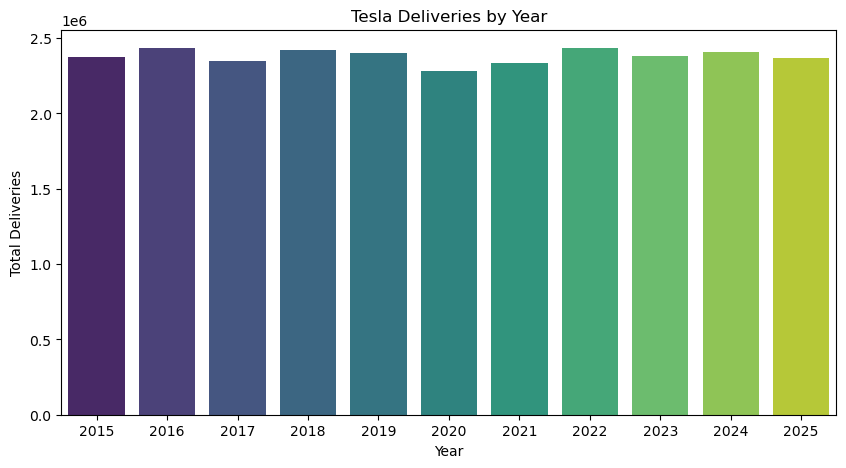

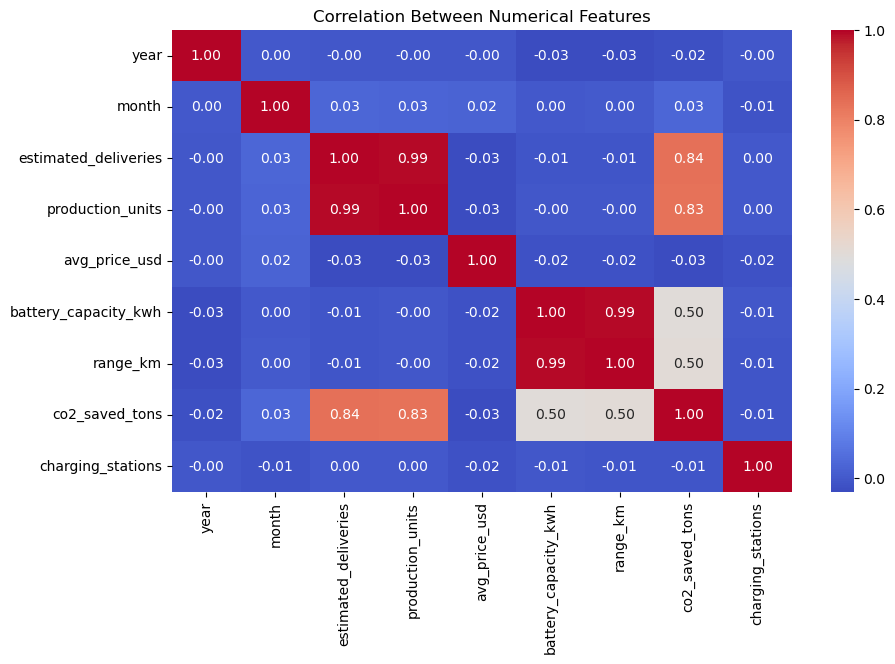


Best Parameters
{'regressor__subsample': 0.8, 'regressor__n_estimators': 100, 'regressor__max_depth': 7, 'regressor__learning_rate': 0.01}
RMSE : 20048.82
R² Score : -0.01


14:13:48 - cmdstanpy - INFO - Chain [1] start processing
14:13:50 - cmdstanpy - INFO - Chain [1] done processing


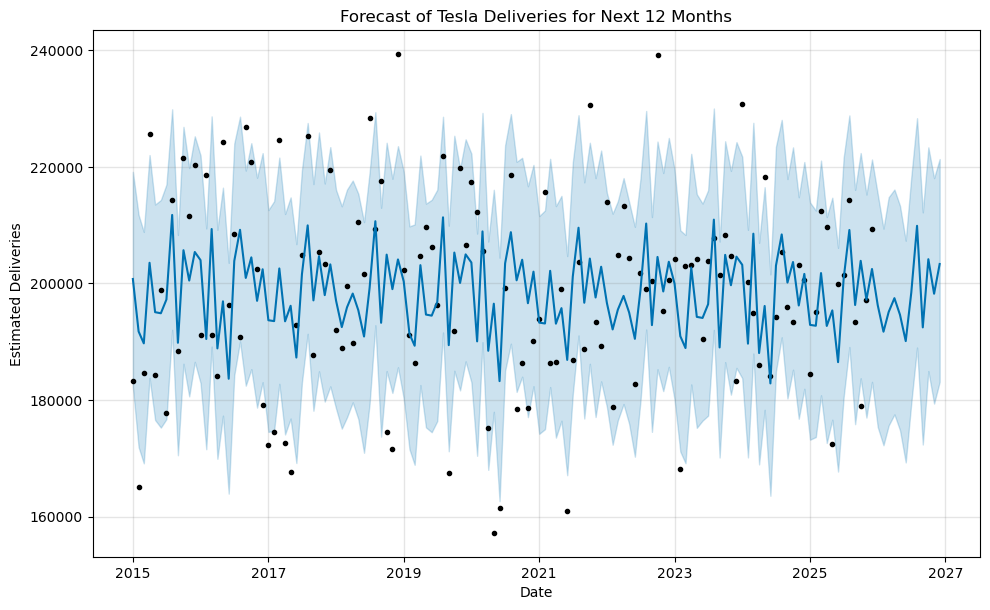

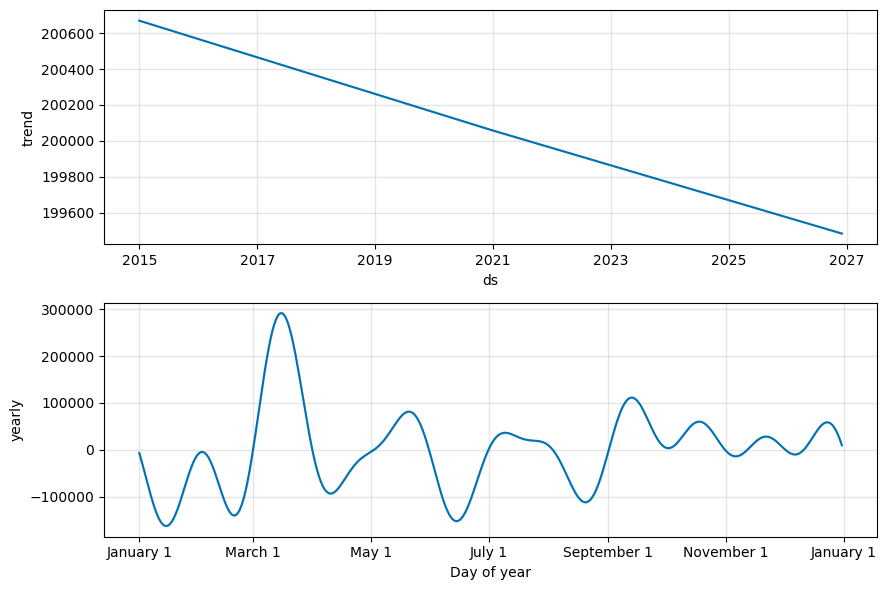

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor
from prophet import Prophet


# Load Dataset

path="resources/tesla_deliveries_dataset_2015_2025.csv"
tesla_df = pd.read_csv(path)

# Standardize column names
tesla_df.columns = (
    tesla_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Dataset Shape:", tesla_df.shape)
print(tesla_df.head())


# Missing Value Treatment


numeric_cols = tesla_df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = tesla_df.select_dtypes(
    include=["object"]
).columns

# Numerical -> median
for col in numeric_cols:
    tesla_df[col] = tesla_df[col].fillna(
        tesla_df[col].median()
    )

# Categorical -> mode
for col in categorical_cols:
    tesla_df[col] = tesla_df[col].fillna(
        tesla_df[col].mode()[0]
    )


# Exploratory Data Analysis

# Year-wise deliveries
deliveries_by_year = (
    tesla_df.groupby("year")["estimated_deliveries"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=deliveries_by_year,
    x="year",
    y="estimated_deliveries",
    palette="viridis"
)

plt.title("Tesla Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Total Deliveries")
plt.show()


# Correlation Heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    tesla_df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()


# Feature Engineering

# Create datetime column
tesla_df["date"] = pd.to_datetime(
    tesla_df["year"].astype(str)
    + "-"
    + tesla_df["month"].astype(str)
    + "-01"
)

# Production-to-delivery ratio
tesla_df["production_delivery_ratio"] = (
    tesla_df["production_units"]
    / (tesla_df["estimated_deliveries"] + 1e-5)
)

# Sort chronologically
tesla_df = tesla_df.sort_values(
    "date"
).reset_index(drop=True)


# XGBoost Regression Model
# Predicting Average Vehicle Price

target_column = "avg_price_usd"

feature_columns = [
    "year",
    "region",
    "model",
    "estimated_deliveries",
    "production_units",
    "battery_capacity_kwh",
    "range_km"
]

# Keep only columns that actually exist
feature_columns = [
    col for col in feature_columns
    if col in tesla_df.columns
]

X = tesla_df[feature_columns]
y = tesla_df[target_column]

# Time-aware split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

categorical_features = [
    col for col in ["region", "model"]
    if col in X.columns
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

model_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", xgb)
])

param_grid = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__learning_rate": [0.01, 0.05, 0.1],
    "regressor__max_depth": [3, 5, 7],
    "regressor__subsample": [0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

price_predictions = best_model.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(y_test, price_predictions)
)

r2 = r2_score(
    y_test,
    price_predictions
)

print("\nBest Parameters")
print(search.best_params_)

print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.2f}")

# Time Series Forecasting with Prophet

# Aggregate monthly deliveries
delivery_series = (
    tesla_df.groupby("date")["estimated_deliveries"]
    .sum()
    .reset_index()
)

delivery_series.columns = ["ds", "y"]

# Train Prophet model
forecast_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

forecast_model.fit(delivery_series)

# Forecast next 12 months
future_dates = forecast_model.make_future_dataframe(
    periods=12,
    freq="MS"
)

forecast = forecast_model.predict(
    future_dates
)

# Forecast plot
forecast_model.plot(forecast)
plt.title(
    "Forecast of Tesla Deliveries for Next 12 Months"
)
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

# Trend + seasonality plots
forecast_model.plot_components(forecast)
plt.show()